# Gram-Type Classification
We build one conformal envelope trained on true-label NC score vectors:
- **gram-neg** phage: NC = raw score
- **gram-pos** phage: NC = 1 − raw score

Both classes cluster near the origin in NC space after this transformation.

### Missing value handling (no imputation)
- **Collapsed 1D**: uses `np.nanmean` — NaN dimensions are simply excluded from the mean
- **Strip**: follows the professor's suggestion — for a missing dimension i₀, replace the  conditional bin limit q_{i₀,k} with the marginal quantile q'_{i₀} computed over all S1 points
- **Radial**: computes magnitudes and directions only over non-NaN dimensions per point

No global imputation is applied. Each method handles NaN natively.

In [1]:
import os
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

### Loading the Data

In [2]:
SCORES_PATH = "../../Data/host_type_all_preds.csv"
METADATA_PATH = "../../Data/metadata.csv"
SPLITS_PATH = "../../Data/all_random_pc_splits.pkl"
alpha = 0.1

print("Loading scores...")
t0 = time.time()
scores_df = pd.read_csv(SCORES_PATH, index_col="proteinID")
print(f"  scores shape : {scores_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
meta_df = meta_df[["accession", "host_type", "split"]]
print(f"  metadata shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading splits...")
t0 = time.time()
with open(SPLITS_PATH, "rb") as f:
    pc_splits = pickle.load(f)
pc_splits = pc_splits.reindex(scores_df.index)
print(f"  splits shape : {pc_splits.shape}  ({time.time()-t0:.1f}s)")

Loading scores...
  scores shape : (1853074, 40)  (3.0s)
Loading metadata...
  metadata shape : (1853074, 3)  (3.3s)
Loading splits...
  splits shape : (1853074, 2160)  (5.8s)


### Protein-Level Contamination Masking
**FIX:** gram-type predictions use ONE simple per-protein split value (`meta_df["split"]`,
values 0-4), NOT the per-host-function splits in `all_random_pc_splits.pkl`. That file's
masking logic is for the 54 separate host-function models used in host classification —
using it here was masking out ~96% of the data (keeping only entries where every matching
host-function model also happened to have that protein in fold 0), instead of the correct
~33% (one clean split per protein, matching `metadata.csv`'s own `split` column).

Mask the protein's score to NaN unless `meta_df["split"] == 0` (the designated test fold
for the gram-type model). No per-function column matching needed.

In [3]:
score_cols = [c for c in scores_df.columns if c.startswith("host_type_")]
print("Preparing protein-level scores...")
t0 = time.time()

# We keep the raw scores intact here so folds 1-4 have data during training.
scores_masked = scores_df[score_cols].copy()

print(f"  Done in {time.time()-t0:.1f}s")
original_nans = scores_df[score_cols].isna().sum().sum()
print(f"  NaNs in dataset: {original_nans:,}")

Preparing protein-level scores...
  Done in 2.1s
  NaNs in dataset: 71,271,481


### Protein-to-Phage Aggregation (NaN-aware mean pooling)

In [4]:
combined = scores_masked.join(meta_df, how="inner")
phage_scores = combined.groupby("accession")[score_cols].mean()
phage_meta = combined.groupby("accession")[["host_type", "split"]].first()
phage_df = phage_scores.join(phage_meta)
phage_df["split"] = phage_df["split"].astype(int)

print(f"Phage-level shape: {phage_df.shape}")
print("\nGram-type distribution:")
print(phage_df["host_type"].value_counts())
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())

Phage-level shape: (18474, 42)

Gram-type distribution:
host_type
gram-neg    10735
gram-pos     7708
unknown        31
Name: count, dtype: int64

Split distribution:
split
0    4433
1    3173
2    3646
3    3588
4    3634
Name: count, dtype: int64


### Train / Test Split

In [5]:
raw = scores_df[score_cols].join(meta_df[["accession", "host_type", "split"]], how="inner")
phage_raw_scores = raw.groupby("accession")[score_cols].mean()
phage_raw_meta = raw.groupby("accession")[["host_type", "split"]].first()
phage_raw = phage_raw_scores.join(phage_raw_meta)

print("Score separation: TEST fold (0) vs TRAIN folds (1-4) — on RAW, unmasked data\n")
for split_group, label in [(phage_raw["split"] == 0, "TEST (fold 0)"),
                            (phage_raw["split"] != 0, "TRAIN (folds 1-4)")]:
    subset = phage_raw[split_group]
    for gt in ["gram-neg", "gram-pos"]:
        mask = subset["host_type"] == gt
        vals = subset.loc[mask, score_cols].values
        print(f"  {label:18s} | {gt:9s}: mean={np.nanmean(vals):.4f}  "
              f"std={np.nanstd(vals):.4f}  NaN%={np.isnan(vals).mean()*100:.1f}%  n={mask.sum()}")
    print()   

Score separation: TEST fold (0) vs TRAIN folds (1-4) — on RAW, unmasked data

  TEST (fold 0)      | gram-neg : mean=0.0546  std=0.1060  NaN%=36.5%  n=2811
  TEST (fold 0)      | gram-pos : mean=0.9187  std=0.1501  NaN%=33.4%  n=1611

  TRAIN (folds 1-4)  | gram-neg : mean=0.0607  std=0.1169  NaN%=30.6%  n=7924
  TRAIN (folds 1-4)  | gram-pos : mean=0.9132  std=0.1471  NaN%=33.9%  n=6097



In [6]:
train_all_folds_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

train_all_folds_df = train_all_folds_df[train_all_folds_df["host_type"].isin(["gram-neg", "gram-pos"])]
test_df = test_df[test_df["host_type"].isin(["gram-neg", "gram-pos"])]

valid_cols = score_cols
K          = len(valid_cols)

print(f"Training phages (folds 1-4) : {len(train_all_folds_df)}")
print(f"Test phages (fold  0)       : {len(test_df)}")
print(f"Score columns (K)           : {K}")
print(f"\nTrain gram-type distribution:")
print(train_all_folds_df["host_type"].value_counts())
print(f"\nTest gram-type distribution:")
print(test_df["host_type"].value_counts())

Training phages (folds 1-4) : 14021
Test phages (fold  0)       : 4422
Score columns (K)           : 40

Train gram-type distribution:
host_type
gram-neg    7924
gram-pos    6097
Name: count, dtype: int64

Test gram-type distribution:
host_type
gram-neg    2811
gram-pos    1611
Name: count, dtype: int64


In [7]:
import numpy as np

print("Score separation: TEST fold (0) vs TRAIN folds (1-4)")
print("(if this is a real single train/test split, TRAIN should look")
print(" noticeably more confident/separated than TEST — overfitting signature)\n")

for split_group, label in [(phage_df["split"] == 0, "TEST (fold 0)"),
                            (phage_df["split"] != 0, "TRAIN (folds 1-4)")]:
    subset = phage_df[split_group]
    for gt in ["gram-neg", "gram-pos"]:
        mask = subset["host_type"] == gt
        mean_score = np.nanmean(subset.loc[mask, valid_cols].values)
        std_score  = np.nanstd(subset.loc[mask, valid_cols].values)
        print(f"  {label:18s} | {gt:9s}: mean={mean_score:.4f}  std={std_score:.4f}  n={mask.sum()}")
    print()

Score separation: TEST fold (0) vs TRAIN folds (1-4)
(if this is a real single train/test split, TRAIN should look
 noticeably more confident/separated than TEST — overfitting signature)

  TEST (fold 0)      | gram-neg : mean=0.0546  std=0.1060  n=2811
  TEST (fold 0)      | gram-pos : mean=0.9187  std=0.1501  n=1611

  TRAIN (folds 1-4)  | gram-neg : mean=0.0607  std=0.1169  n=7924
  TRAIN (folds 1-4)  | gram-pos : mean=0.9132  std=0.1471  n=6097



### Score Characteristics Check
Verify gram-neg mean ≈ 0.07 and gram-pos mean ≈ 0.65.
If both are near 0.5 the masking wiped out all signal.
NaN fractions are also reported — these will be handled natively by each method.

In [8]:
print("Mean score per gram type (training set, NaN ignored):")
for gt in ["gram-neg", "gram-pos"]:
    mask = train_all_folds_df["host_type"] == gt
    mean_score = np.nanmean(train_all_folds_df.loc[mask, valid_cols].values)
    median_score = np.nanmedian(train_all_folds_df.loc[mask, valid_cols].values)
    nan_frac = train_all_folds_df.loc[mask, valid_cols].isna().mean().mean()
    print(f"  {gt}: mean={mean_score:.4f}, median={median_score:.4f}, NaN%={nan_frac*100:.1f}%, n={mask.sum()}")

col_means = pd.DataFrame({
    "gram-neg": train_all_folds_df[train_all_folds_df["host_type"]=="gram-neg"][valid_cols].mean(),
    "gram-pos": train_all_folds_df[train_all_folds_df["host_type"]=="gram-pos"][valid_cols].mean(),
})
col_means["gram-neg > gram-pos"] = col_means["gram-neg"] > col_means["gram-pos"]
print(f"\nColumns where gram-neg scores higher: {col_means['gram-neg > gram-pos'].sum()} / {K}")

test_raw    = test_df[valid_cols].values      # shape (n_test, K), may contain NaN
test_labels = test_df["host_type"].to_numpy(dtype=str)

Mean score per gram type (training set, NaN ignored):
  gram-neg: mean=0.0607, median=0.0156, NaN%=30.6%, n=7924
  gram-pos: mean=0.9132, median=0.9714, NaN%=33.9%, n=6097

Columns where gram-neg scores higher: 0 / 40


### Utility Functions

In [9]:
def split_data_by_fold(df, valid_cols, test_fold_id):
    df = df.copy()
    df["split"] = df["split"].astype(int)
    s1_df = df[df["split"] != test_fold_id]
    s2_df = df[df["split"] == test_fold_id]
    return (s1_df[valid_cols].values, s2_df[valid_cols].values, s1_df["host_type"].to_numpy(dtype=str), s2_df["host_type"].to_numpy(dtype=str))

def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0: return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

### Radial Envelope
- magnitudes and cosine similarities are computed only over the non-NaN dimensions of each point. This means:
    - A phage missing dimension k contributes a magnitude computed over its K-1 available dims
    - The sector check is done only in the available subspace
    - No imputation is needed — missing dimensions are simply excluded per point

In [10]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

def radial_build_envelope(S1, S2, labels_S1, labels_S2, alpha, M=200, delta_deg=30):
    """
    NaN-native radial envelope.
    For each S1 point, magnitude and direction are computed over non-NaN dims only.
    For each S2 point, the tau score is computed over non-NaN dims only.
    """
    N1, K = S1.shape
    U = sample_positive_sphere(M, K)
    cos_thresh = np.cos(np.radians(delta_deg))

    # Per-point NaN-aware magnitude and direction for S1
    S1_clean = np.where(np.isnan(S1), 0.0, S1)   # zero-fill for linear algebra only
    mags = np.array([np.linalg.norm(S1[n, ~np.isnan(S1[n])]) for n in range(N1)])
    dirs = np.zeros((N1, K))
    for n in range(N1):
        valid = ~np.isnan(S1[n])
        mag_n = mags[n]
        if mag_n > 1e-12:
            dirs[n, valid] = S1[n, valid] / mag_n

    # Per-direction local boundary q_tilde
    q_tilde = np.zeros(M)
    for m in range(M):
        cos_sims = dirs @ U[m]          # (N1,) — missing dims contribute 0 to dot product
        nearby = cos_sims >= cos_thresh
        src_mags = mags[nearby] if nearby.sum() > 5 else mags
        q_tilde[m] = np.quantile(src_mags, 1 - alpha)

    # Tau scores for S2 — NaN-aware
    N2 = S2.shape[0]
    tau_scores = np.zeros(N2)
    boundary = U * q_tilde[:, None]   # (M, K)
    for n in range(N2):
        valid = ~np.isnan(S2[n])
        if valid.sum() == 0:
            tau_scores[n] = 0.0
            continue
        # For each direction m, compute max ratio over valid dims
        ratios_m = (S2[n, valid][None, :] /
                    (boundary[:, valid] + 1e-12)).max(axis=1)   # (M,)
        tau_scores[n] = ratios_m.min()

    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": max(t_hat_neg, t_hat_pos), "method": "radial"}

def radial_is_in_region(scores, envelope):
    """NaN-native: check each point only over its available dimensions."""
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]   # (M, K)
    N = scores.shape[0]
    inside = np.zeros(N, dtype=bool)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            inside[n] = True   # no information — conservative: include
            continue
        # Inside if any sector covers this point in its available dims
        inside[n] = np.any(np.all(scores[n, valid][None, :] <= boundary[:, valid], axis=1))
    return inside

### Strip Envelope — NaN-Native 
- if dimension i₀ is missing for a test point, replace the conditional bin limit $q_{i₀,k}$ (quantile of dim i₀ in bin k of dim j) with the marginal quantile $q'_{i₀}$ (unconditional quantile of dim i₀ over all S1).
- This relaxes the constraint for the missing dimension rather than ignoring it entirely or filling it with an imputed value. 
- It is conservative: a missing dimension gets the widest reasonable bound, not a fabricated score.

In [11]:
def strip_shape_discovery(S1, alpha, M):
    """
    Builds bin limits and also computes marginal quantiles for each dimension.
    Marginal quantiles are used as fallback when a dimension is missing at test time.
    """
    N1, K = S1.shape
    bin_edges = np.array([np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), M + 1) for j in range(K)])
    limits = np.zeros((K, K, M))
    # Marginal (1-alpha) quantile for each dimension i over all S1 — NaN-aware
    marginal_quantiles = np.array([np.nanquantile(S1[:, i], 1 - alpha) for i in range(K)])
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            # Only use S1 points that have a non-NaN value in dimension j
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                # Points in strip that also have non-NaN in dim i
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() >= 3:
                    limits[j, i, m] = np.quantile(S1[src_mask, i], 1 - alpha)
                else:
                    # Fallback: use all non-NaN values in dim i
                    non_nan_i = S1[~np.isnan(S1[:, i]), i]
                    limits[j, i, m] = (np.quantile(non_nan_i, 1 - alpha) if len(non_nan_i) > 0 else marginal_quantiles[i])
    # Monotonicity propagation
    for j in range(K):
        for i in range(K):
            if i == j: continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits, marginal_quantiles

def get_bin_indices(scores, bin_edges):
    """NaN values get bin index 0 — their dimension will be handled via marginal fallback."""
    K = scores.shape[1]
    M = bin_edges.shape[1] - 1
    return np.array([np.clip(np.where(np.isnan(scores[:, j]), 0, np.digitize(scores[:, j], bin_edges[j]) - 1), 0, M - 1) for j in range(K)]).T

def strip_tau_scores(S, bin_edges, limits, marginal_quantiles):
    """
    Compute tau score for each point in S.
    For a point missing dimension i: replace the conditional limit with marginal_quantiles[i].
    For a point missing dimension j: skip all constraints that bin on j (they are uninformative).
    """
    N, K = S.shape
    bin_idx = get_bin_indices(S, bin_edges)   # (N, K)
    ratios = np.zeros((N, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]     # conditional limit, shape (N,)
            s_i = S[:, i]
            nan_i = np.isnan(s_i)
            nan_j = np.isnan(S[:, j])
            # Points missing dim j: constraint bins on j are meaningless — skip (ratio = 0)
            # Points missing dim i: use marginal quantile as the limit (professor's fix)
            # Points with both available: standard ratio
            ratio = np.zeros(N)
            # Standard case: both dims available
            both_avail = (~nan_i) & (~nan_j)
            ratio[both_avail] = s_i[both_avail] / (lims[both_avail] + 1e-12)
            # Missing dim i, dim j available: replace conditional limit with marginal
            miss_i = nan_i & (~nan_j)
            ratio[miss_i] = marginal_quantiles[i] / (lims[miss_i] + 1e-12)
            # Missing dim j: contribute 0 (constraint not applicable)
            # ratio already 0 for these
            ratios[:, j, i] = ratio
    return ratios.max(axis=(1, 2))

def strip_build_envelope(S1, S2, labels_S1, labels_S2, alpha, M=20):
    bin_edges, limits, marginal_quantiles = strip_shape_discovery(S1, alpha, M)
    tau_scores = strip_tau_scores(S2, bin_edges, limits, marginal_quantiles)
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    return {
        "bin_edges"          : bin_edges,
        "limits"             : limits,
        "marginal_quantiles" : marginal_quantiles,
        "t_hat"              : max(t_hat_neg, t_hat_pos),
        "method"             : "strip"
    }

def strip_is_in_region(scores, envelope):
    bin_edges = envelope["bin_edges"]
    limits = envelope["limits"]
    marginal_quantiles = envelope["marginal_quantiles"]
    t_hat = envelope["t_hat"]
    N, K = scores.shape
    bin_idx = get_bin_indices(scores, bin_edges)
    ratios = np.zeros((N, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            s_i = scores[:, i]
            nan_i = np.isnan(s_i)
            nan_j = np.isnan(scores[:, j])
            ratio = np.zeros(N)
            both_avail = (~nan_i) & (~nan_j)
            ratio[both_avail] = s_i[both_avail] / (lims[both_avail] + 1e-12)
            miss_i = nan_i & (~nan_j)
            ratio[miss_i] = marginal_quantiles[i] / (lims[miss_i] + 1e-12)
            ratios[:, j, i] = ratio
    return ratios.max(axis=(1, 2)) <= t_hat

### Collapsed 1D Envelope — NaN-Native
Uses `np.nanmean` throughout. NaN dimensions are excluded from the mean automatically.
No imputation of any kind needed.

In [12]:
def collapsed_build_envelope(S1, S2, labels_S1, labels_S2, alpha):
    """nanmean ignores NaN — no imputation needed."""
    S1_1d = np.nanmean(S1, axis=1, keepdims=True)
    S2_1d = np.nanmean(S2, axis=1, keepdims=True)
    q_tilde = np.nanquantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    return {"q_tilde": q_tilde, "t_hat": max(t_hat_neg, t_hat_pos), "method": "collapsed"}

def collapsed_is_in_region(scores, envelope):
    scores_1d = np.nanmean(scores, axis=1)   # NaN dims excluded automatically
    return scores_1d <= envelope["q_tilde"] * envelope["t_hat"]

In [13]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial": return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip": return strip_is_in_region(scores, envelope)
    return collapsed_is_in_region(scores, envelope)

### Prediction

In [14]:
def compute_tau(scores, envelope):
    """
    For each point, compute the minimum scaling factor t such that
    the point would fall inside the envelope scaled by t.
    tau < 1 means inside, tau > 1 means outside.
    Used for the empty-set fallback: pick the hypothesis with smaller tau.
    """
    method = envelope["method"]
    N = scores.shape[0]
    tau = np.zeros(N)

    if method == "collapsed":
        scores_1d = np.nanmean(scores, axis=1)
        denom     = envelope["q_tilde"] * envelope["t_hat"]
        tau       = scores_1d / (denom + 1e-12)

    elif method == "strip":
        # Reuse strip_tau_scores and normalise by t_hat
        raw_tau = strip_tau_scores(scores, envelope["bin_edges"],
                                   envelope["limits"], envelope["marginal_quantiles"])
        tau = raw_tau / (envelope["t_hat"] + 1e-12)

    elif method == "radial":
        boundary = envelope["U"] * (envelope["q_tilde"] * envelope["t_hat"])[:, None]
        for n in range(N):
            valid = ~np.isnan(scores[n])
            if valid.sum() == 0:
                tau[n] = 0.0
                continue
            ratios_m = (scores[n, valid][None, :] /
                        (boundary[:, valid] + 1e-12)).max(axis=1)
            tau[n] = ratios_m.min()

    return tau

In [ ]:
def predict_gram_type_nc(test_raw, envelope, rng=None):
    """
    For each test phage, check two hypotheses:
      gram-neg: NC = raw score
      gram-pos: NC = 1 - raw score

    If both hypotheses fall outside the envelope (empty set), declare total uncertainty 
    by returning both possibilities: ["gram-neg", "gram-pos"].
    This conservative fallback set expansion preserves valid coverage without forcing 
    an arbitrary point prediction.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    nc_gramneg = test_raw.copy()
    nc_grampos = np.where(np.isnan(test_raw), np.nan, 1.0 - test_raw)

    in_gramneg = is_in_region(nc_gramneg, envelope)
    in_grampos = is_in_region(nc_grampos, envelope)

    tau_neg = compute_tau(nc_gramneg, envelope)
    tau_pos = compute_tau(nc_grampos, envelope)

    results = []
    for i in range(len(test_raw)):
        pred_set = []
        if in_gramneg[i]: pred_set.append("gram-neg")
        if in_grampos[i]: pred_set.append("gram-pos")

        if len(pred_set) == 0:
            # Biologically sound fallback: instead of forcing a wrong guess on an outlier,
            # declare total uncertainty by returning both possibilities.
            pred_set = ["gram-neg", "gram-pos"]
            # neg_nan = np.isnan(tau_neg[i])
            # pos_nan = np.isnan(tau_pos[i])
            # if neg_nan and pos_nan:
            #     pred_set.append("gram-neg" if rng.random() < 0.5 else "gram-pos")
            # elif neg_nan:
            #     pred_set.append("gram-pos")
            # elif pos_nan:
            #     pred_set.append("gram-neg")
            # elif tau_neg[i] < tau_pos[i]:
            #     pred_set.append("gram-neg")
            # elif tau_pos[i] < tau_neg[i]:
            #     pred_set.append("gram-pos")
            # else:
            #     pred_set.append("gram-neg" if rng.random() < 0.5 else "gram-pos")

        results.append({
            "in_gramneg"     : bool(in_gramneg[i]),
            "in_grampos"     : bool(in_grampos[i]),
            "prediction_set" : pred_set,
            "forced"         : (not in_gramneg[i]) and (not in_grampos[i])
        })
    return results

### Evaluation

In [16]:
def evaluate(results, true_labels, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)
    empty = sum(s == 0 for s in set_sizes)
    size2 = sum(s == 2 for s in set_sizes)
    # Add this line inside evaluate(), after computing covered:
    forced = sum(1 for r in results if r.get("forced", False))
    
    return {
        "coverage"          : covered / n,
        "avg_set_size"      : np.mean(set_sizes),
        "empty_rate"        : empty / n,
        "singleton_rate"    : len(singletons) / n,
        "size2_rate"        : size2 / n,
        "singleton_accuracy": (correct_singletons / len(singletons) if singletons else None),
        "set_sizes"         : set_sizes,
        "per_type_coverage" : {
            gt: sum(true_labels[i] in results[i]["prediction_set"]
                    for i in range(n) if true_labels[i] == gt)
               / max(1, sum(lbl == gt for lbl in true_labels))
            for gt in ["gram-neg", "gram-pos"]
        },
    }

### Final Evaluation on Fold 0
Training data (folds 1-4) is shuffled then split 50/50 into S1 and S2.
Shuffling is critical — without it the split may be gram-type imbalanced,
causing t_hat to collapse for gram-pos.
All three methods receive raw arrays with NaN intact — no imputation applied.

In [17]:
print("\n" + "="*55)
print(" TRAINING FINAL ENVELOPES & TESTING ON SPLIT 0 ")
print("="*55)


# --- NEW INNER-FOLD SPLITTING LOGIC ---
fold0_df = phage_df[phage_df["split"] == 0].copy()
fold0_df = fold0_df[fold0_df["host_type"].isin(["gram-neg", "gram-pos"])]

fold0_shuffled = fold0_df.sample(frac=1, random_state=42)
n = len(fold0_shuffled)
n_s1, n_s2 = int(n * 0.4), int(n * 0.3)   # 40% shape / 30% calibration / 30% final test

final_s1     = fold0_shuffled.iloc[:n_s1]
final_s2     = fold0_shuffled.iloc[n_s1 : n_s1 + n_s2]
holdout_test = fold0_shuffled.iloc[n_s1 + n_s2 :]

print(f"Shape discovery (S1) : {len(final_s1)}")
print(f"Calibration (S2)     : {len(final_s2)}")
print(f"Final held-out test  : {len(holdout_test)}")

# Raw arrays — Target Fold 0 slices, NaN intact, no imputation
s1_raw = final_s1[valid_cols].values
s2_raw = final_s2[valid_cols].values
labels_s1 = final_s1["host_type"].to_numpy(dtype=str)
labels_s2 = final_s2["host_type"].to_numpy(dtype=str)

print(f"S1 distribution: {dict(zip(*np.unique(labels_s1, return_counts=True)))}")
print(f"S2 distribution: {dict(zip(*np.unique(labels_s2, return_counts=True)))}")

# NC transformation — NaN propagates correctly
S1_nc = np.where(labels_s1[:, None] == "gram-neg", s1_raw, 1.0 - s1_raw)
S2_nc = np.where(labels_s2[:, None] == "gram-neg", s2_raw, 1.0 - s2_raw)

# Build all three envelopes on the same data
print("\nBuilding envelopes...")
t0 = time.time()
final_r_env = radial_build_envelope(S1_nc, S2_nc, labels_s1, labels_s2, alpha, M=200)
print(f"  Radial done     ({time.time()-t0:.1f}s)")

t0 = time.time()
final_s_env = strip_build_envelope(S1_nc, S2_nc, labels_s1, labels_s2, alpha, M=20)
print(f"  Strip done      ({time.time()-t0:.1f}s)")

t0 = time.time()
final_c_env = collapsed_build_envelope(S1_nc, S2_nc, labels_s1, labels_s2, alpha)
print(f"  Collapsed done  ({time.time()-t0:.1f}s)")

test_raw_holdout = holdout_test[valid_cols].values
test_labels_holdout = holdout_test["host_type"].to_numpy(dtype=str)

# Predict strictly on your new unseen inner-fold-0 holdout partition
final_r_res = predict_gram_type_nc(test_raw_holdout, final_r_env)
final_s_res = predict_gram_type_nc(test_raw_holdout, final_s_env)
final_c_res = predict_gram_type_nc(test_raw_holdout, final_c_env)

# Evaluate metrics on the pristine holdout labels
test_metrics = {}
for key, res in [("radial", final_r_res), ("strip", final_s_res), ("collapsed", final_c_res)]:
    test_metrics[key] = evaluate(res, test_labels_holdout, alpha)

methods_names = ["Radial", "Strip", "Collapsed 1D"]
method_keys = ["radial", "strip", "collapsed"]
rows = []
for name, key in zip(methods_names, method_keys):
    m = test_metrics[key]
    set_sizes = m["set_sizes"]
    n_total = len(set_sizes)
    rows.append({
        "Method"        : name,
        "Coverage"      : f"{m['coverage']:.3f}",
        "Neg coverage"  : f"{m['per_type_coverage']['gram-neg']:.3f}",
        "Pos coverage"  : f"{m['per_type_coverage']['gram-pos']:.3f}",
        "Avg set size"  : f"{m['avg_set_size']:.3f}",
        "Empty %"       : f"{(sum(1 for s in set_sizes if s == 0)/n_total)*100:.1f}%",
        "Size-2 %"      : f"{(sum(1 for s in set_sizes if s == 2)/n_total)*100:.1f}%",
        "Singleton acc.": f"{m['singleton_accuracy']:.3f}" if m["singleton_accuracy"] else "N/A"
    })

print("\n=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===")
print(pd.DataFrame(rows).to_string(index=False))


 TRAINING FINAL ENVELOPES & TESTING ON SPLIT 0 
Shape discovery (S1) : 1768
Calibration (S2)     : 1326
Final held-out test  : 1328
S1 distribution: {np.str_('gram-neg'): np.int64(1110), np.str_('gram-pos'): np.int64(658)}
S2 distribution: {np.str_('gram-neg'): np.int64(855), np.str_('gram-pos'): np.int64(471)}

Building envelopes...
  Radial done     (0.1s)
  Strip done      (2.8s)
  Collapsed done  (0.0s)

=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===
      Method Coverage Neg coverage Pos coverage Avg set size Empty % Size-2 % Singleton acc.
      Radial    0.998        0.999        0.998        1.053    0.0%     5.3%          0.998
       Strip    0.998        0.999        0.998        1.059    0.0%     5.9%          0.998
Collapsed 1D    0.998        0.999        0.998        1.050    0.0%     5.0%          0.998


### Comparison Plots

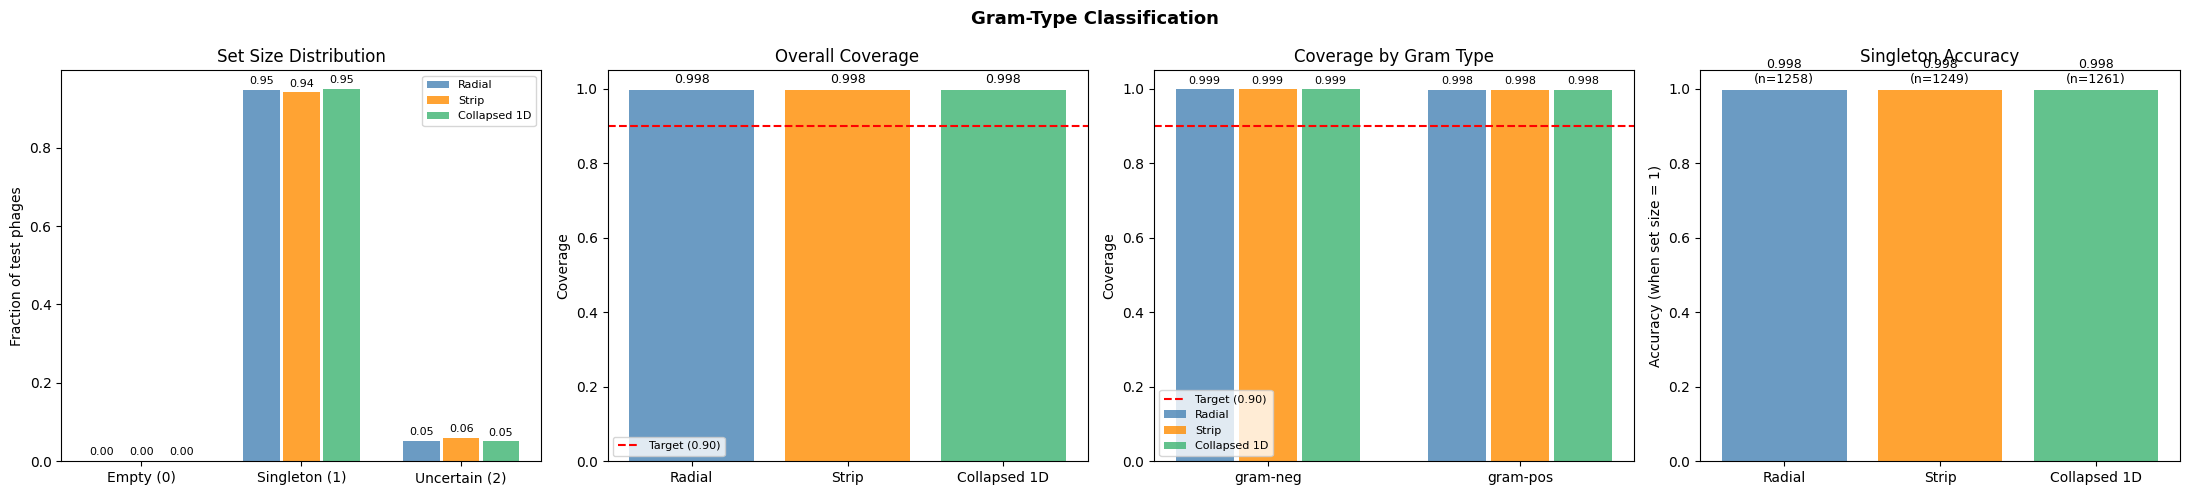

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors  = ["steelblue", "darkorange", "mediumseagreen"]
offsets = [-0.25, 0.0, 0.25]

# Plot 1: Set size distribution
ax = axes[0]
x = np.array([0, 1, 2])
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    m = test_metrics[key]
    n_total = len(m["set_sizes"])
    fracs = [sum(1 for sz in m["set_sizes"] if sz == s) / n_total for s in [0, 1, 2]]
    bars = ax.bar(x + offset, fracs, width=0.23, label=name, color=c, alpha=0.8)
    for rect, val in zip(bars, fracs):
        ax.text(rect.get_x() + rect.get_width()/2, val + 0.01, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Empty (0)", "Singleton (1)", "Uncertain (2)"])
ax.set_title("Set Size Distribution"); ax.set_ylabel("Fraction of test phages"); ax.legend(fontsize=8)

# Plot 2: Overall coverage
ax = axes[1]
means = [test_metrics[k]["coverage"] for k in method_keys]
bars = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05); ax.set_title("Overall Coverage"); ax.set_ylabel("Coverage"); ax.legend(fontsize=8)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Plot 3: Per-class coverage
ax = axes[2]
gram_types = ["gram-neg", "gram-pos"]
x = np.arange(len(gram_types))
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    rates = [test_metrics[key]["per_type_coverage"][gt] for gt in gram_types]
    bars = ax.bar(x + offset, rates, width=0.23, label=name, color=c, alpha=0.8)
    for rect, val in zip(bars, rates):
        ax.text(rect.get_x() + rect.get_width()/2, val + 0.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=8)

ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_xticks(x); ax.set_xticklabels(gram_types)
ax.set_ylim(0, 1.05); ax.set_title("Coverage by Gram Type"); ax.set_ylabel("Coverage"); ax.legend(fontsize=8)

# Plot 4: Singleton accuracy
ax = axes[3]
accuracies = [test_metrics[k]["singleton_accuracy"] or 0 for k in method_keys]
ns = [int(test_metrics[k]["singleton_rate"] * len(test_metrics[k]["set_sizes"])) for k in method_keys]
bars = ax.bar(methods_names, accuracies, color=colors, alpha=0.8)
ax.set_ylim(0, 1.05); ax.set_title("Singleton Accuracy"); ax.set_ylabel("Accuracy (when set size = 1)")
for bar, val, n_s in zip(bars, accuracies, ns):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}\n(n={n_s})", ha="center", va="bottom", fontsize=9)

plt.suptitle("Gram-Type Classification", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### Score Distribution

DISTRIBUTION OF MEAN RAW SCORES PER PHAGE (TEST SPLIT 0)
  Overall: mean=0.370, std=0.420

  gram-neg: mean=0.055, std=0.054, n=2811

  gram-pos: mean=0.918, std=0.066, n=1611


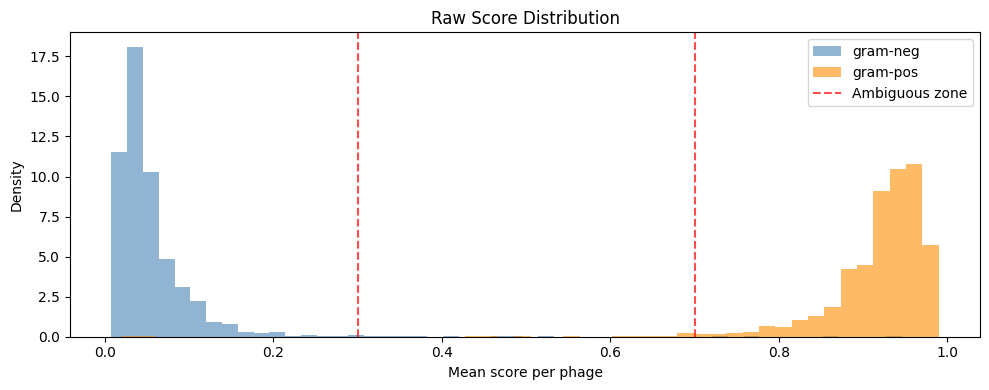

In [19]:
print("DISTRIBUTION OF MEAN RAW SCORES PER PHAGE (TEST SPLIT 0)")

mean_scores = np.nanmean(test_df[valid_cols].values, axis=1)
print(f"  Overall: mean={np.nanmean(mean_scores):.3f}, std={np.nanstd(mean_scores):.3f}")
for gt in ["gram-neg", "gram-pos"]:
    mask = test_df["host_type"] == gt
    scores = mean_scores[mask]
    print(f"\n  {gt}: mean={np.nanmean(scores):.3f}, std={np.nanstd(scores):.3f}, n={mask.sum()}")    

plt.figure(figsize=(10, 4))
for gt, col in [("gram-neg", "steelblue"), ("gram-pos", "darkorange")]:
    mask = test_df["host_type"] == gt
    plt.hist(mean_scores[mask], bins=50, alpha=0.6, color=col, label=gt, density=True)
plt.axvline(0.3, color="red", linestyle="--", alpha=0.7, label="Ambiguous zone")
plt.axvline(0.7, color="red", linestyle="--", alpha=0.7)
plt.xlabel("Mean score per phage")
plt.ylabel("Density")
plt.title("Raw Score Distribution")
plt.legend(); plt.tight_layout(); plt.show()  

In [20]:
# Export gram-type prediction SETS for every phage, for use in host classification
all_raw = phage_df[valid_cols].values
all_results = predict_gram_type_nc(all_raw, final_c_env)   # collapsed = most robust of the three

print("phage_df index name:", phage_df.index.name)  # sanity check — should say "accession"

gram_pred_df = pd.DataFrame({
    "accession": phage_df.index,
    "pred_gramneg": [("gram-neg" in r["prediction_set"]) for r in all_results],
    "pred_grampos": [("gram-pos" in r["prediction_set"]) for r in all_results],
})
gram_pred_df.to_csv(f"gram_type_predictions.csv", index=False)
print(f"Saved {len(gram_pred_df)} predictions")
print(gram_pred_df[["pred_gramneg", "pred_grampos"]].value_counts())

phage_df index name: accession
Saved 18474 predictions
pred_gramneg  pred_grampos
True          False           10241
False         True             6826
True          True             1407
Name: count, dtype: int64
